# **Examining Occupational Stereotypes (Ngrams)**
## **Goal**: Test relationships between occupational demographics and professions' feminization–masculinization.

### **Setup**
#### Imports

In [14]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

import math
import os
import getpass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

from ngramprep.common.w2v_model import W2VModel
from analyze.cosine_similarity_time_series import cosine_similarity_over_years, plot_nearest_neighbors
from analyze.weat_time_series import compute_weat_over_years
from analyze.dimension_projection_time_series import compute_projection_over_years, compute_baseline_set
from analyze.pca_dimension_time_series import compute_pca_dimension_over_years
from analyze.semantic_drift import track_local_semantic_change, track_global_semantic_change, track_directional_drift
from analyze.average_relatedness_by_year import track_word_relatedness
from analyze.bls_utils import calculate_women_percentage, scrape_bls_professions_csv_batch
from analyze.ipums_utils import (
    aggregate_ipums_professions_csv,
    aggregate_ipums_professions_csv_batch,
    fetch_and_aggregate_ipums_professions_csv,
    fetch_ipums_microdata_cps,
)
from ipumspy import IpumsApiClient, MicrodataExtract

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Specify model directory

In [2]:
model_path =  '/scratch/edk202/NLP_models/Google_Books/20200217/eng/5gram_files/models_final/norm_and_align'

### **Generate gender projection**
#### Use the `compute_meandiff_dimension` method to create a masculinization dimension

In [17]:
year = 2019
model = W2VModel(f'{model_path}/w2v_y{year}_wbnone_vs300_w004_mc001_sg1_e010.kv')

gender_contrasts = [
    ('she', 'he'),
    ('her', 'his'),
    ('herself', 'himself'),
    ('woman', 'man'),
    ('women', 'men'),
    ('girl', 'boy'),
    ('girls', 'boys'),
    ('mother', 'father'),
    ('mothers', 'fathers'),
    ('daughter', 'son'),
    ('daughters', 'sons'),
    ('sister', 'brother'),
    ('sisters', 'brothers')
]

meandiff_result = model.compute_meandiff_dimension(
    token_contrasts=gender_contrasts
)

#### Print various words' projections on the masculinization dimension using the `print_word_projections` method

In [18]:
test_words = [
    # Clear anchors
    'husband', 'wife',
    'king', 'queen',

    # Historically masculine-stereotyped professions
    'engineer', 'physicist', 'soldier', 'pilot',
    'firefighter', 'mechanic', 'carpenter',
    'programmer', 'CEO', 'president',
    'construction_worker', 'plumber',

    # Historically feminine-stereotyped professions
    'nurse', 'teacher', 'secretary', 'receptionist',
    'librarian', 'babysitter', 'housekeeper',
    'caregiver', 'assistant', 'hairdresser',

    # Leadership / status roles (interesting test cases)
    'leader', 'manager', 'chairperson',
    'lawyer', 'doctor', 'scientist',
    'professor', 'judge',

    # Trait terms (useful for validating axis content)
    'strong', 'assertive', 'dominant',
    'competitive', 'logical', 'independent',
    'gentle', 'nurturing', 'empathetic',
    'emotional', 'supportive', 'caring'
]

projections = W2VModel.print_word_projections(model, meandiff_result['dimension'], test_words)


────────────────────────────────────────────────────────────────────────────────────────────────────
WORD PROJECTIONS ON DIMENSION
────────────────────────────────────────────────────────────────────────────────────────────────────
Word                           Projection                                           Visualization
────────────────────────────────────────────────────────────────────────────────────────────────────
  king                             0.2173                                              ██████
  leader                           0.1968                                               █████
  soldier                          0.1814                                               █████
  judge                            0.1453                                                ████
  physicist                        0.1350                                                ████
  president                        0.1335                                                ████
  en

### **Examine time-series**
#### Auto-generate a baseline trend using `compute_baseline_set` function

Using shared vocabulary: 27566 words found across all models

Baseline word set selection:
  Total vocabulary:          27,566
  Neutral candidates:        26,586 (after anchor & pattern exclusion)
  Selected neutral words:    22,834 (passed stability thresholds)

  Selection thresholds:
    |mu| < 0.080  (mean projection)
    |beta| < 0.0100  (trend/year)
    sigma < 0.150  (temporal variability)
    n >= 5  (minimum years)

  Neutral word statistics:
    Mean |mu|:     0.0323
    Mean |beta|:   0.0004
    Mean sigma:    0.0372

  Over-time correlation:
    Mean:          0.5051
    Median:        0.5038
    Std:           0.1124
    Range:         [0.2458, 0.7964]

  Aggregation:               mean



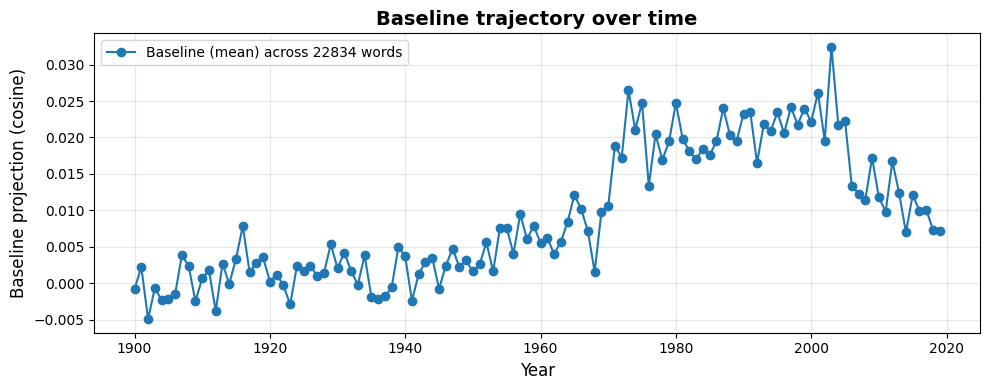

In [19]:
baseline_source = compute_baseline_set(
    model_dir=model_path,
    contrast_pairs=gender_contrasts,
    start_year=1900,
    end_year=2019,
    year_step=1,
    method='meandiff',
    exclusion_pattern=r"(man|men|woman|women|girl|boy|girls|boys|mother|father|mothers|fathers|daughter|son|daughters|sons|sister|brother)",
    eps_mean=0.08,
    eps_trend=0.010,
    eps_sigma=0.15,
    min_years=5,
    agg="mean",
    corr_n_permutations=0,
    verbose=True,
    plot_baseline=True
)

baseline_source = baseline_source["baseline"]

#### Altneratively, specify a set of baseline words

In [20]:
baseline_source = [
    'table', 'chair', 'window', 'door', 'wall', 'floor', 'roof', 'tree', 'leaf', 'branch', 'root', 'flower',
    'grass', 'water', 'stone', 'rock', 'sand', 'soil', 'clay', 'book', 'page', 'paper', 'pen', 'ink', 'cup',
    'plate', 'bowl', 'spoon', 'knife', 'fork', 'bread', 'cheese', 'butter', 'salt', 'sugar', 'road', 'path',
    'bridge', 'gate', 'fence', 'box', 'bag', 'basket', 'bottle', 'jar', 'horse', 'cow', 'sheep', 'pig',
    'chicken', 'dog', 'cat', 'sun', 'moon', 'star', 'cloud', 'rain', 'wind', 'river', 'lake', 'mountain',
    'hill', 'valley', 'wood', 'metal', 'iron', 'gold', 'silver', 'wheel', 'rope', 'chain', 'nail', 'hammer'
]

#### Specify the set of occupations from Caliskan et al. (2017)

In [21]:
targets = [
    "technician", "accountant", "supervisor", "engineer", "worker", "educator", "clerk", "counselor",
    "inspector", "mechanic", "manager", "therapist", "administrator", "salesperson", "receptionist", "librarian",
    "advisor", "pharmacist", "janitor", "psychologist", "physician", "carpenter", "nurse", "investigator",
    "bartender", "specialist", "electrician", "officer", "pathologist", "teacher", "lawyer", "planner",
    "practitioner", "plumber", "instructor", "surgeon", "veterinarian", "paramedic", "examiner", "chemist",
    "machinist", "appraiser", "nutritionist", "architect", "hairdresser", "baker", "programmer", "paralegal",
    "hygienist", "scientist"
]

#### Compute and plot masculinization time-series

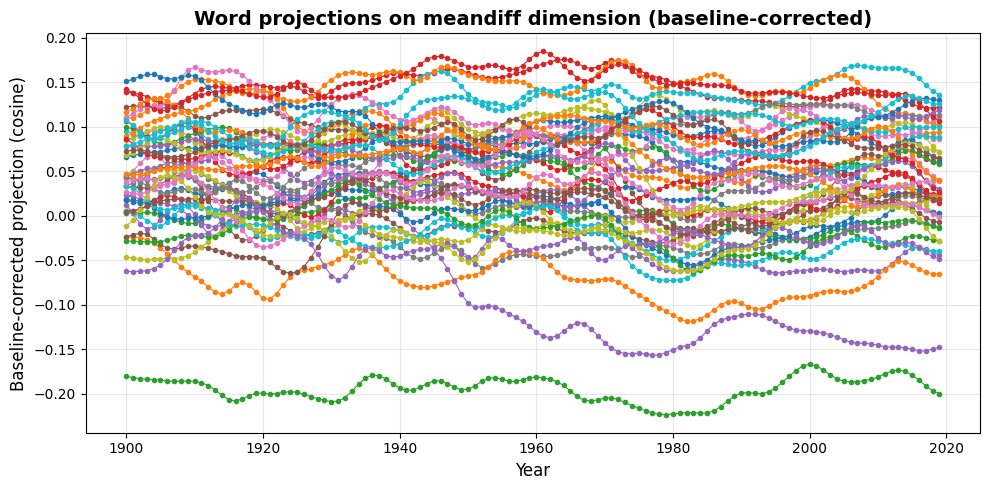

In [22]:
result = compute_projection_over_years(
    model_dir=model_path,
    token_contrasts=gender_contrasts,
    test_words=targets,
    start_year=1900,
    end_year=2019,
    year_step=1,
    method='meandiff',
    ensure_sign_positive=True,
    smooth=True,
    sigma=2,
    verbose=False,
    baseline_source=baseline_source,
    plot_corrected_if_baseline=True,
    plot=True,
 )

Using IPUMS data: /scratch/edk202/lexichron/ipums_api_downloads/professionsIPUMS_2015.csv
Matched 46/50 professions in IPUMS data
Using baseline-corrected projections
Valid professions (non-NaN projections): 43 out of 46
Filtered out 3 professions with NaN projections

=== Correlation Results (Baseline-corrected) ===
Pearson r = -0.6414
p-value = 0.000004
n = 43 professions


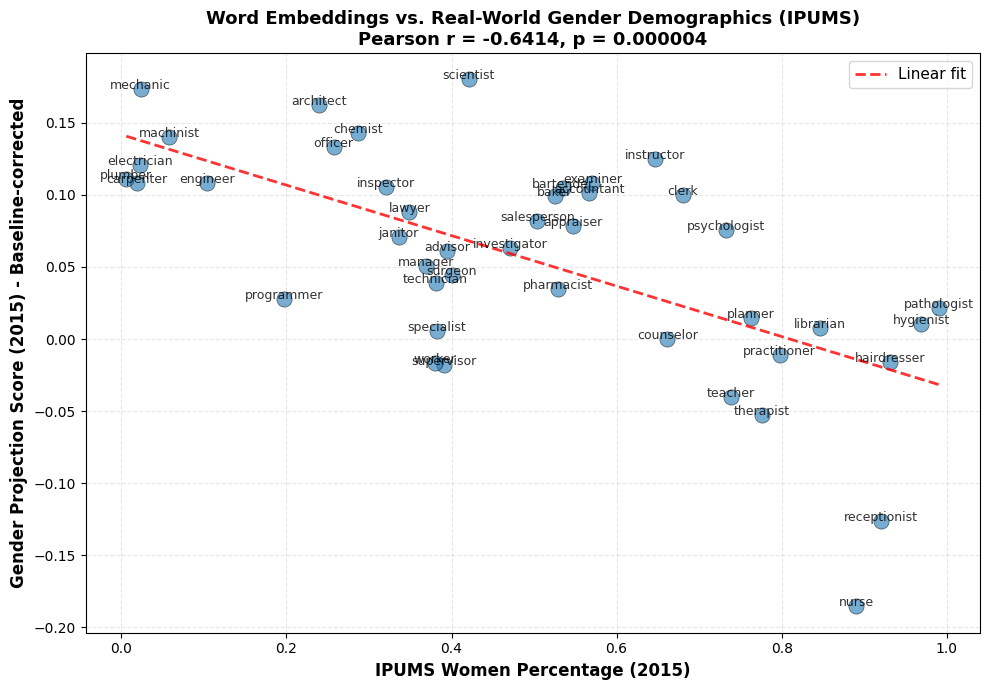


✓ Significant correlation (p < 0.05)


In [23]:
# Correlation analysis with NaN handling and baseline correction option
year_of_interest = 2015
use_baseline_corrected = True  # Set to True to use baseline-corrected projections if available

# --- Resolve IPUMS CSV path for the year of interest ---
ipums_results = result_df  # batch results DataFrame from the IPUMS download cell
year_row = ipums_results.loc[
    (ipums_results['year'] == year_of_interest) & (ipums_results['status'] == 'ok')
]
if year_row.empty:
    available = sorted(ipums_results.loc[ipums_results['status'] == 'ok', 'year'].tolist())
    raise ValueError(
        f"No IPUMS CSV for year {year_of_interest}. "
        f"Available years: {available}"
    )
demo_csv_path = year_row.iloc[0]['output_csv']
print(f"Using IPUMS data: {demo_csv_path}")

# Compute women percentages for all targets
demo_percentages = {}
for profession in targets:
    try:
        pct = calculate_women_percentage(demo_csv_path, profession)
        demo_percentages[profession] = pct
    except (ZeroDivisionError, ValueError):
        pass

print(f"Matched {len(demo_percentages)}/{len(targets)} professions in IPUMS data")

# Determine which projection data to use
if use_baseline_corrected and result.get('baseline_applied') and not result['projections_corrected'].empty:
    proj_year = result['projections_corrected'].loc[year_of_interest]
    projection_type = "Baseline-corrected"
    print(f"Using baseline-corrected projections")
else:
    proj_year = result['projections'].loc[year_of_interest]
    projection_type = "Raw"
    print(f"Using raw projections")

# Create common_profs: professions with both demographic data and projections for this year
common_profs = [p for p in targets if p in demo_percentages and p in proj_year.index]

# Filter to professions with valid (non-NaN) projection values
valid_profs = [p for p in common_profs if not pd.isna(proj_year[p])]

print(f"Valid professions (non-NaN projections): {len(valid_profs)} out of {len(common_profs)}")
print(f"Filtered out {len(common_profs) - len(valid_profs)} professions with NaN projections")

# Extract values for valid professions
demo_vals = np.array([demo_percentages[p] for p in valid_profs])
proj_vals = np.array([proj_year[p] for p in valid_profs])

# Compute correlation
if len(valid_profs) >= 3:
    corr, p_value = pearsonr(demo_vals, proj_vals)
    
    print(f"\n=== Correlation Results ({projection_type}) ===")
    print(f"Pearson r = {corr:.4f}")
    print(f"p-value = {p_value:.6f}")
    print(f"n = {len(valid_profs)} professions")
    
    # Create scatter plot
    plt.figure(figsize=(10, 7))
    plt.scatter(demo_vals, proj_vals, alpha=0.6, s=120, edgecolors='black', linewidth=0.5)
    
    # Add profession labels
    for i, prof in enumerate(valid_profs):
        plt.annotate(prof, (demo_vals[i], proj_vals[i]), 
                    fontsize=9, alpha=0.8, ha='center')
    
    # Add regression line
    z = np.polyfit(demo_vals, proj_vals, 1)
    p = np.poly1d(z)
    x_line = np.linspace(demo_vals.min(), demo_vals.max(), 100)
    plt.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2, label=f'Linear fit')
    
    plt.xlabel(f"IPUMS Women Percentage ({year_of_interest})", fontsize=12, fontweight='bold')
    plt.ylabel(f"Gender Projection Score ({year_of_interest}) - {projection_type}", fontsize=12, fontweight='bold')
    plt.title(f"Word Embeddings vs. Real-World Gender Demographics (IPUMS)\nPearson r = {corr:.4f}, p = {p_value:.6f}", 
              fontsize=13, fontweight='bold')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()
    
    # Print interpretation
    if p_value < 0.05:
        print(f"\n✓ Significant correlation (p < 0.05)")
    else:
        print(f"\n✗ Not statistically significant (p >= 0.05)")
else:
    print(f"ERROR: Not enough valid professions ({len(valid_profs)} found)")

#### Make file list for BLS data download

In [ ]:
# Regression guard: exact label-column matching in calculate_women_percentage
bls_root = Path("/scratch/edk202/lexichron/bls_scraped")
found_csvs = sorted(bls_root.glob("professionsBLS*.csv"))
assert found_csvs, "No professionsBLS*.csv files found under /scratch/edk202/lexichron/bls_scraped"

csv_path = str(found_csvs[0])
print("Using CSV:", csv_path)

# Positive controls: should resolve to finite percentages
positive_terms = ["engineer", "nurse", "manager"]
for term in positive_terms:
    pct = calculate_women_percentage(csv_path, term)
    assert math.isfinite(pct), f"Expected finite pct for '{term}', got {pct}"
    assert 0.0 <= pct <= 1.0, f"Expected pct in [0,1] for '{term}', got {pct}"

# Negative controls: should NOT match exact label columns
negative_terms = ["and", "man"]
for term in negative_terms:
    try:
        _ = calculate_women_percentage(csv_path, term)
        raise AssertionError(f"Expected no exact label match for '{term}', but got a value")
    except ZeroDivisionError:
        pass

print("✅ Exact label matching regression check passed")

### **IPUMS workflow**
#### Convert IPUMS microdata to BLS-compatible yearly profession CSVs

In [ ]:
# IPUMS extract configuration (edit paths/column names to match your extract)
ipums_extract_file = '/scratch/edk202/lexichron/notebooks/ipums_extract.csv'
ipums_occ_map_file = '/scratch/edk202/lexichron/notebooks/ipums_occ1990_map.csv'  # columns: code,label
ipums_output_dir = '/scratch/edk202/lexichron/notebooks/ipums_scraped'

# Export one BLS-compatible CSV per year
ipums_runs_df = aggregate_ipums_professions_csv_batch(
    extract_file=ipums_extract_file,
    output_dir=ipums_output_dir,
    output_basename='professionsIPUMS.csv',
    occupation_code_col='OCC1990',
    occupation_label_col=None,
    occupation_map_file=ipums_occ_map_file,
    year_col='YEAR',
    sex_col='SEX',
    race_col='RACE',
    hispanic_col='HISPAN',
    weight_col='PERWT',
    female_codes=(2,),
    black_codes=(2,),
    asian_codes=(4, 5, 6),
    non_hispanic_codes=(0, 9),
    min_total_employed=50,
    continue_on_error=True,
    inject_year_in_filename=True,
    years=None,  # set e.g. [1990, 2000, 2010] to limit
 )

print(f"Completed: {(ipums_runs_df['status'] == 'ok').sum()} succeeded, {(ipums_runs_df['status'] == 'failed').sum()} failed")
ipums_runs_df.head(10)

In [ ]:
# Smoke test: IPUMS -> BLS-compatible CSV -> exact profession lookup
smoke_extract = '/scratch/edk202/lexichron/notebooks/ipums_extract_smoketest.csv'
smoke_map = '/scratch/edk202/lexichron/notebooks/ipums_occ1990_map_smoketest.csv'
smoke_out_dir = Path('/scratch/edk202/lexichron/notebooks/ipums_smoketest_out')
smoke_out_dir.mkdir(parents=True, exist_ok=True)

runs = aggregate_ipums_professions_csv_batch(
    extract_file=smoke_extract,
    output_dir=str(smoke_out_dir),
    years=[2010, 2011],
    output_basename='professionsIPUMS_smoke.csv',
    occupation_code_col='OCC1990',
    occupation_label_col=None,
    occupation_map_file=smoke_map,
    year_col='YEAR',
    sex_col='SEX',
    race_col='RACE',
    hispanic_col='HISPAN',
    weight_col='PERWT',
    female_codes=(2,),
    black_codes=(2,),
    asian_codes=(4, 5, 6),
    non_hispanic_codes=(0, 9),
    min_total_employed=1,
    continue_on_error=False,
    inject_year_in_filename=True,
 )

assert (runs['status'] == 'ok').all(), f"Batch failed:\n{runs}"

csv_2010 = runs.loc[runs['year'] == 2010, 'output_csv'].iloc[0]
csv_2011 = runs.loc[runs['year'] == 2011, 'output_csv'].iloc[0]

eng_2010 = calculate_women_percentage(csv_2010, 'engineer')
nurse_2010 = calculate_women_percentage(csv_2010, 'nurse')

# 2010 expected values from synthetic data:
# engineers = women weight (120+80) / total (100+120+80) = 200/300 = 0.6667
# nurses = women weight 200 / total (200+50) = 200/250 = 0.8
assert math.isclose(eng_2010, 2/3, rel_tol=1e-3), f"Unexpected engineer pct: {eng_2010}"
assert math.isclose(nurse_2010, 0.8, rel_tol=1e-3), f"Unexpected nurse pct: {nurse_2010}"

print('✅ IPUMS smoke test passed')
runs

#### Live IPUMS CPS ASEC download
Fetches the most recent CPS ASEC extract with harmonized occupation codes (`OCC2010`) and person weights (`ASECWT`).
Auto-discovers the latest ASEC sample, submits/waits/downloads, and decompresses `.gz` files in place.

In [16]:
result_df = fetch_and_aggregate_ipums_professions_csv(
    occupation_map_file='/scratch/edk202/lexichron/ipums_occ2010_map.csv',
    api_key='59cba10d8a5da536fc06b59d0d34a8b208154b9684e7d4fadbe0a339',
    years=range(1968, 2026),
    download_dir='/scratch/edk202/lexichron/ipums_api_downloads',
)

STEP 1: Fetch data from IPUMS API
Discovering available CPS ASEC samples...
  Resolved years [1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025] -> samples ['cps1968_03s', 'cps1969_03s', 'cps1970_03s', 'cps1971_03s', 'cps1972_03s', 'cps1973_03s', 'cps1974_03s', 'cps1975_03s', 'cps1976_03s', 'cps1977_03s', 'cps1978_03s', 'cps1979_03s', 'cps1980_03s', 'cps1981_03s', 'cps1982_03s', 'cps1983_03s', 'cps1984_03s', 'cps1985_03s', 'cps1986_03s', 'cps1987_03s', 'cps1988_03s', 'cps1989_03s', 'cps1990_03s', 'cps1991_03s', 'cps1992_03s', 'cps1993_03s', 'cps1994_03s', 'cps1995_03s', 'cps1996_03s', 'cps1997_03s', 'cps1998_03s', 'cps1999_03s', 'cps2000_03s', 'cps2001_03s', 'cps2002_03s', 'cps2003_03s', 'cps20

In [26]:
# Build long-format panel: (profession, year, women_pct, projection)
# for mixed-effects modelling of projection ~ women_pct + (1 | profession)

use_baseline_corrected_panel = True

# Pick projection DataFrame (years × professions)
if use_baseline_corrected_panel and result.get('baseline_applied') and not result['projections_corrected'].empty:
    proj_df = result['projections_corrected']
    print("Using baseline-corrected projections")
else:
    proj_df = result['projections']
    print("Using raw projections")

# Get successfully aggregated IPUMS years
ok_years = result_df.loc[result_df['status'] == 'ok'].set_index('year')

# Determine overlapping years (present in both projections and IPUMS)
proj_years = set(proj_df.index)
ipums_years = set(ok_years.index)
panel_years = sorted(proj_years & ipums_years)
print(f"Projection years: {min(proj_df.index)}–{max(proj_df.index)} ({len(proj_df)} total)")
print(f"IPUMS years: {sorted(ipums_years)[:3]}...{sorted(ipums_years)[-3:]}")
print(f"Overlapping years for panel: {len(panel_years)}")

# Assemble panel rows
panel_rows = []
for yr in panel_years:
    csv_path = ok_years.loc[yr, 'output_csv']
    # Get women percentages for each target profession
    for profession in targets:
        # Projection value
        if profession not in proj_df.columns:
            continue
        proj_val = proj_df.loc[yr, profession]
        if pd.isna(proj_val):
            continue
        # Women percentage from IPUMS CSV
        try:
            wpct = calculate_women_percentage(csv_path, profession)
        except (ZeroDivisionError, ValueError, KeyError):
            continue
        panel_rows.append({
            'profession': profession,
            'year': yr,
            'women_pct': wpct,
            'projection': proj_val,
        })

panel_df = pd.DataFrame(panel_rows)
print(f"\nPanel: {len(panel_df)} observations, "
      f"{panel_df['profession'].nunique()} professions, "
      f"{panel_df['year'].nunique()} years")
panel_df.head(10)

Using baseline-corrected projections
Projection years: 1900–2019 (120 total)
IPUMS years: [1968, 1969, 1970]...[2023, 2024, 2025]
Overlapping years for panel: 52

Panel: 2139 observations, 43 professions, 52 years


,profession,year,women_pct,projection
0,technician,1968,0.122403,0.002075
1,accountant,1968,0.238000,0.071337
2,supervisor,1968,0.076104,0.041400
3,engineer,1968,0.008669,0.149667
4,worker,1968,0.276712,-0.005366
5,clerk,1968,0.653870,0.094615
6,inspector,1968,0.479000,0.124302
7,mechanic,1968,0.004361,0.132328
8,manager,1968,0.151638,0.081441
9,therapist,1968,0.663000,-0.099002


In [28]:
import statsmodels.formula.api as smf

# Mundlak/Bell decomposition: separate within- and between-profession effects
# - women_pct_between: profession's time-averaged women% (cross-sectional differences)
# - women_pct_within:  deviation from profession mean (longitudinal change over time)

prof_means = panel_df.groupby('profession')['women_pct'].transform('mean')
panel_df['women_pct_between'] = prof_means
panel_df['women_pct_within'] = panel_df['women_pct'] - prof_means

# Decomposed model: projection ~ within + between + (1 | profession)
model_me = smf.mixedlm(
    "projection ~ women_pct_within + women_pct_between",
    data=panel_df,
    groups=panel_df["profession"],
)
result_me = model_me.fit()
print(result_me.summary())
print("\n--- Interpretation ---")
print(f"Between-profession effect (β_between): {result_me.fe_params['women_pct_between']:.4f}")
print(f"  → Cross-sectional: occupations with higher avg women% have {'more feminine' if result_me.fe_params['women_pct_between'] < 0 else 'more masculine'} projections")
print(f"Within-profession effect (β_within):  {result_me.fe_params['women_pct_within']:.4f}")
print(f"  → Longitudinal: as a profession's women% rises over time, its projection shifts {'toward feminine' if result_me.fe_params['women_pct_within'] < 0 else 'toward masculine'}")

           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  projection
No. Observations:   2139     Method:              REML      
No. Groups:         43       Scale:               0.0008    
Min. group size:    17       Log-Likelihood:      4453.6147 
Max. group size:    52       Converged:           Yes       
Mean group size:    49.7                                    
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept          0.118    0.016  7.541 0.000  0.087  0.149
women_pct_within  -0.025    0.007 -3.694 0.000 -0.038 -0.012
women_pct_between -0.183    0.030 -6.117 0.000 -0.241 -0.124
Group Var          0.003    0.023                           


--- Interpretation ---
Between-profession effect (β_between): -0.1826
  → Cross-sectional: occupations with higher avg women% have more feminine projections

/scratch/edk202/.conda/envs/lexichron/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
